# COVID-19 in Newfoundland and Labrador

This [Jupyter Lab](https://jupyter.org/) notebook analyzes a data set on COVID-19 cases in Canada. The intention is to test the effectiveness of the [Gompertz function](https://en.wikipedia.org/wiki/Gompertz_function) in describing and predicting the total number of COVID-19 cases, specifically in Newfoundland and Labrador.

## Introduction

The **Gompertz function** is defined by Wikipedia as, "a sigmoid function which describes growth as being slowest at the start and end of a given time period." It is commonly used in modelling many forms of biological growth, including the growth of animals and plants in size, the growth of tumour cells in the body and so on. Can the Gompertz function also describe and predict the growth of COVID-19?

To answer this question, we will create a model centered around the Gompertz function, using it to fit a curve to a record of the total number of COVID-19 cases in the province. From evaluating the accuracy of the results, we should be able to get a good impression of the effectiveness of the Gompertz function in modelling the growth of the pandemic.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime
import numpy as np
import math
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = pd.read_csv("https://health-infobase.canada.ca/src/data/covidLive/covid19-download.csv")
# Convert totalcases to a number, eliminating any NA results created in the process.
data['totalcases'] = pd.to_numeric(data['totalcases'],errors="coerce")
data = data.dropna(subset='totalcases')
# Convert date from a string into a proper datetime.
data['date'] = pd.to_datetime(data['date'])
# Narrow the data set down to fields relevant to Newfoundland and Labrador.
data = data[data['prname'] == "Newfoundland and Labrador"]
# To avoid instances of division by zero, we'll only consider case numbers
# greater than zero.
data = data[data['totalcases'] != 0]

Now that the basic data tidying is complete, it's possible to proceed with defining the Gompertz function itself. A **training** and **test** data set will also be created by partitioning the original data set; 80% of the records will be used for training the model and the remaining 20% will be used to test its effectiveness.

In [15]:
# Define the Gompertz function.
def gompertz(x, A, B, C):
    return A * np.exp(-B * np.exp(-C * x))

# Split the data into two groups, 80% of which will be used for training the
# model and 20% of which will be used for testing its effectiveness.
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# Split into X and y for both training and testing sets
X_train = train_data.drop('totalcases', axis=1)
y_train = train_data['totalcases']
X_test = test_data.drop('totalcases', axis=1)
y_test = test_data['totalcases']

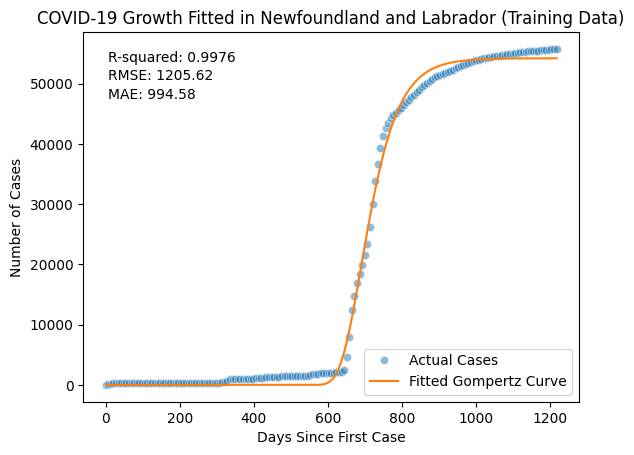

In [16]:
X_train['days'] = (X_train['date'] - X_train['date'].min()).dt.days

# These are the initial guesses for the parameters A, B and C in our function.
initial_guess = [y_train.max(), 1, 0.01]

# Fit the Gompertz curve to the training data set.
params, covariance = curve_fit(gompertz, X_train['days'], y_train, p0=initial_guess)

# Generate fitted values based on the optimized parameters.
X_train['fitted_cases'] = gompertz(X_train['days'], *params)

# Calculate the residuals.
residuals = y_train - X_train['fitted_cases']

# Calculate R-squared.
ss_total = np.sum((y_train - np.mean(y_train))**2)  # Total sum of squares.
ss_residual = np.sum(residuals**2)  # Residual sum of squares.
r_squared = 1 - (ss_residual / ss_total)

# Calculate Root Mean Squared Error (RMSE).
rmse = np.sqrt(mean_squared_error(y_train, X_train['fitted_cases']))

# Calculate Mean Absolute Error (MAE).
mae = mean_absolute_error(y_train, X_train['fitted_cases'])

# Create a scatter plot of the number of actual cases in the training data.
sns.lineplot(x=X_train['days'], y=y_train, label='Actual Cases', color='tab:blue', marker='o', linestyle='None',alpha=0.5)

# Plot the fitted Gompertz curve to the training data.
sns.lineplot(x=X_train['days'], y=X_train['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')
plt.title("COVID-19 Growth Fitted in Newfoundland and Labrador (Training Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)
plt.text(0.05, 0.95, f"R-squared: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.show()



The model has been trained using a subset of the original data set. We can now evaluate its performance against the test data set.

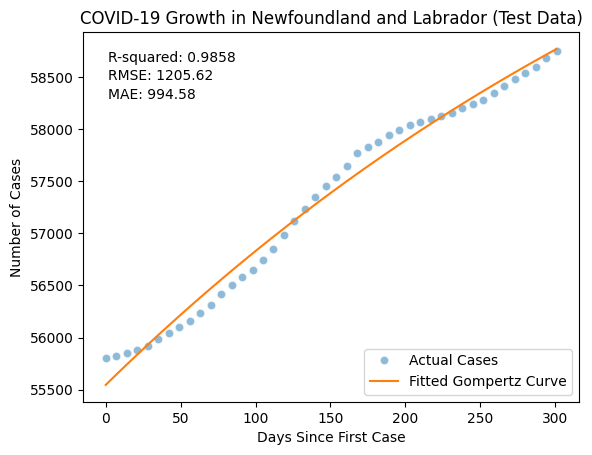

In [23]:
X_test['days'] = (X_test['date'] - X_test['date'].min()).dt.days

initial_guess = [y_test.max(), 1, 0.01]

params, covariance = curve_fit(gompertz, X_test['days'], y_test, p0=initial_guess)

X_test['fitted_cases'] = gompertz(X_test['days'], *params)

# Calculate the residuals.
residuals = y_test - X_test['fitted_cases']

# Calculate R-squared.
ss_total = np.sum((y_test- np.mean(y_test))**2)  # Total sum of squares.
ss_residual = np.sum(residuals**2)  # Residual sum of squares.
r_squared = 1 - (ss_residual / ss_total)

# Calculate Root Mean Squared Error (RMSE).
rmse = np.sqrt(mean_squared_error(y_train, X_train['fitted_cases']))

# Calculate Mean Absolute Error (MAE).
mae = mean_absolute_error(y_train, X_train['fitted_cases'])

# Create a scatter plot of the number of actual cases in the test data.
sns.lineplot(x=X_test['days'], y=y_test, label='Actual Cases', color='tab:blue', marker='o', linestyle='None',alpha=0.5)

# Plot the fitted Gompertz curve to the test data.
sns.lineplot(x=X_test['days'], y=X_test['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')
plt.title("COVID-19 Growth in Newfoundland and Labrador (Test Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)
plt.text(0.05, 0.95, f"R-squared: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.show()



The model appears to perform reasonably well against the test data set as well. We are now ready to apply the model to the entirety of the data set.

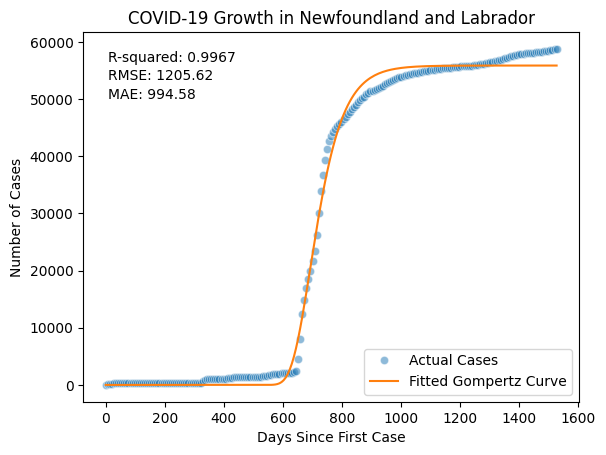

In [18]:
data['days'] = (data['date'] - data['date'].min()).dt.days
                                 
initial_guess = [data['totalcases'].max(),1, 0.01]

params, covariance = curve_fit(gompertz, data['days'], data['totalcases'], p0=initial_guess)

data['fitted_cases'] = gompertz(data['days'], *params)

residuals = data['totalcases'] - data['fitted_cases']

# Calculate summary statistics.
ss_total = np.sum((data['fitted_cases'] - np.mean(data['fitted_cases']))**2)
ss_residual = np.sum(residuals**2)
r_squared = 1 - (ss_residual / ss_total)
rmse = np.sqrt(mean_squared_error(y_train, X_train['fitted_cases']))
mae = mean_absolute_error(y_train, X_train['fitted_cases'])

sns.lineplot(x=data['days'], y=data['totalcases'], label='Actual Cases', color='tab:blue', marker='o', linestyle='None',alpha=0.5)

sns.lineplot(x=data['days'], y=data['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')

plt.text(0.05, 0.95, f"R-squared: {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"RMSE: {rmse:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.85, f"MAE: {mae:.2f}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.title("COVID-19 Growth in Newfoundland and Labrador")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)
plt.show()



## Analysis

### Summary Statistics

The summary statistics on the performace of the model reveal some interesting facts. The **R-squared** value indicates that 99.76% of the variance in the data can indeed be explained by the model. However, the **root mean squared error** (or RMSE) for the model is around 1205, indicating that on average, predictions were off by about 1205 units. The **mean actual error** (or MAE) for the model is approximately 995, meaning that predictions were (on average) 995 units off. Since **RMSE > MAE,** there are obviously some large errors/outliers that affect the RMSE disproportionately.

### Residuals Plot

We can further examine the performance of the model by examining a plot of the residuals.

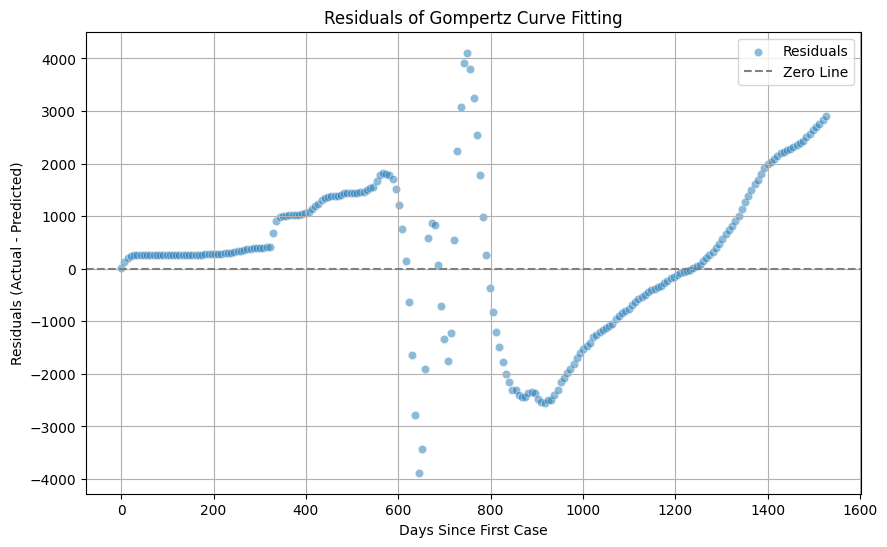

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you already have the Gompertz fitted values stored in 'X_train['fitted_cases']'
# Calculate the residuals
residuals = data['totalcases'] - data['fitted_cases']

# Plot the residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['days'], y=residuals, color='tab:blue', label='Residuals',alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', label='Zero Line')  # Zero line reference
plt.title("Residuals of Gompertz Curve Fitting")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True)
plt.show()


There are clearly systematic patterns in the residuals plot. There are noticeable trends and deviations which suggest that the model does not fully capture certain aspects of the data. From days 0 to about 600, the residuals exhibit an upward trend, indicating **underestimation** in the model. In contrast, after about 800 days the residuals show a downward trend followed by an upward curve, indicating first **overestimation** and then **underestimation** during this time period. Days 600 to 800 shows widely scattered residuals, indicating a **poor fit** during that period.

There is a considerable variation in the spread of the residuals over time. The residuals plot begins with the residuals clustered quite close to zero, but during the period spanning from days 600 to 800, the residuals are widely scattered. There is clearly a **widening** pattern in the residuals after about day 1000. This variation indicates **heteroscedasticity,** in which the variance of the errors change over time.

### Can we improve upon the model?

One way we could potentially address the issue of heteroscedasticity would be to try different transformations of the dependent variable (the total number of cases), in an attempt to determine if one such transformation would result in a better fit for the data. For example, here is a plot of the same data and the same fitted curve, but with a square root transformation applied to the dependent variable.

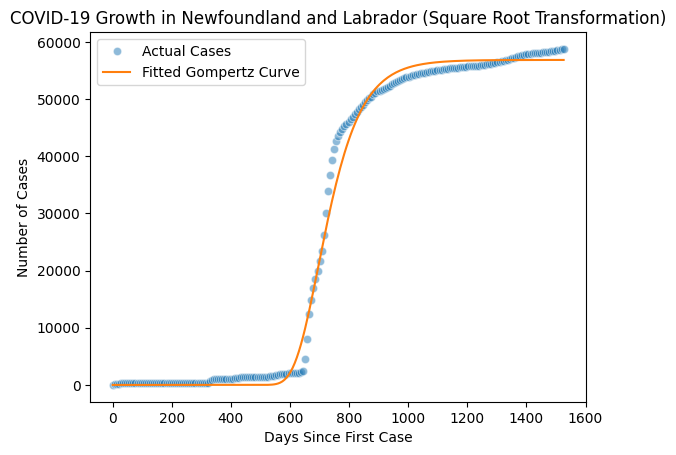

In [20]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

def gompertz(t, A, B, C):
    return A * np.exp(-B * np.exp(-C * t))

# Perform a square root transformation on the dependent variable.
data['sqrt_totalcases'] = np.sqrt(data['totalcases'])

data['days'] = (data['date'] - data['date'].min()).dt.days

initial_guess = [np.sqrt(data['totalcases'].max()), 1, 0.01]

params, covariance = curve_fit(gompertz, data['days'], data['sqrt_totalcases'], p0=initial_guess)

# Generate fitted values, then back-transform them.
data['fitted_sqrt_cases'] = gompertz(data['days'], *params)
data['fitted_cases'] = data['fitted_sqrt_cases']**2

data['residuals'] = data['totalcases'] - data['fitted_cases']

# Calculate summary statistics.
ss_total = np.sum((data['totalcases'] - np.mean(data['totalcases']))**2)
ss_residual = np.sum(residuals**2)
r_squared = 1 - (ss_residual / ss_total)
rmse = np.sqrt(mean_squared_error(data['totalcases'], data['fitted_cases']))
mae = mean_absolute_error(data['totalcases'], data['fitted_cases'])

sns.lineplot(x=data['days'], y=data['totalcases'], label='Actual Cases', color='tab:blue', marker='o', linestyle='None', alpha=0.5)
sns.lineplot(x=data['days'], y=data['fitted_cases'], label='Fitted Gompertz Curve', color='tab:orange')
plt.title("COVID-19 Growth in Newfoundland and Labrador (Square Root Transformation)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(False)
plt.show()



We can examine the effects of the transformation by plotting the residuals again.

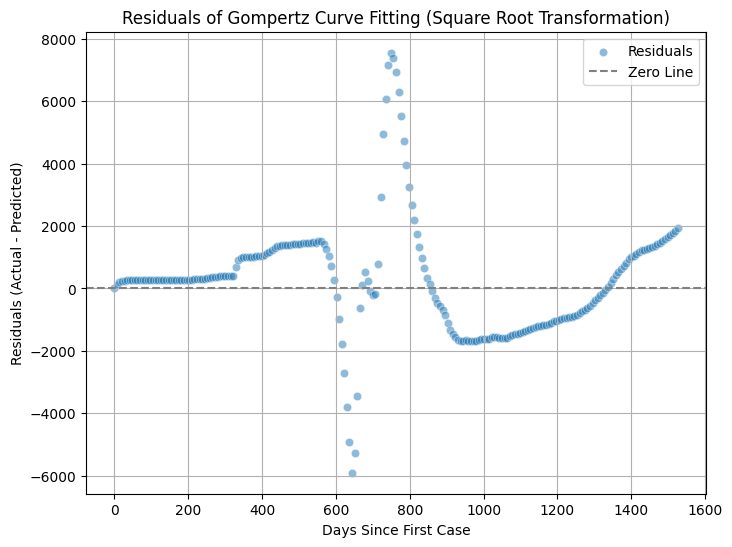

In [21]:
# Residual Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data['days'], y=data['residuals'], color='tab:blue', label='Residuals',alpha=0.5)
plt.axhline(0, color='gray', linestyle='--', label='Zero Line')
plt.title("Residuals of Gompertz Curve Fitting (Square Root Transformation)")
plt.xlabel("Days Since First Case")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.grid(True)
plt.show()

This time there is an even wider spread of the residuals across the zero line. We can conclude that the square root transformation does **not** improve the accuracy of the model.

## Conclusion

Does the Gompertz model provide an adequate basis upon which the total number of COVID-19 cases can be described and predicted? While the curve fitting from such a model produces impressive results, the summary statistics collected, as well as the residual plots, make it clear that such an approach is not sufficient in describing and predicting the progression of the pandemic.

The weaknesses of the Gompertz function in its use for modelling can be summarized as follows:

- The Gompertz function assumes a sigmoidal (S-shaped) curve; it begins with exponential growth, slows down with time, eventually levelling off when reaching an upper asymptote (the carrying capacity). Why do COVID-19 outbreaks deviate from this pattern? There are a number of factors that could be involved, such as multiple waves caused by emerging new variants, changes in public health measures (such as mask mandates and lockdowns).

- The Gompertz function is deterministic; it does not take into account such external factors as government interventions, environmental factors (e.g. seasonality) and so on. As such, its predictions can be inaccurate, as there are a number of external factors that significantly influence total case numbers.

- The Gompertz model assumes a homogenous population, in which every individual has the same likelihood of becoming infected. In reality, populations are **heterogeneous,** with variations in age, general health, mobility and others. It may be that the model oversimplifies the dynamics of COVID-19 and its spread. It may fail to capture the differences in demographic and regional patterns that occur in a heterogeneous population.

- COVID-19 outbreaks occur in multiple waves. The Gompertz model assumes a single outbreak wave; it must be modified in order to accurately model subsequent waves. The outbreak of the disease in Newfoundland and Labrador also occurred in waves, with surges occurring as new variants arrived in the province. As such, the Gompertz model may be ineffective in describing and predicting its spread in this case.

- Data on COVID-19 outbreaks are often of poor quality, containing overreporting or underreporting of cases, delays in reporting, even differences in testing policies. The Gompertz model is highly sensitive to data quality; poor quality data can lead to significant errors, both in parameter estimation and prediction. A closer examination of the data set would be necessary to determine whether or not the recording standards and testing policies used by Newfoundland and Labrador were accurate and consistent. In either case, if they were not, the Gompertz model would be sensitive to this.

- The parameters of the Gompertz model are fixed once fitted. This makes the model less adaptable, in particular to events like sudden drops or surges in cases, as well as dynamics introduced by government intervention or behavioural changes. In reality, Newfoundland and Labrador enforced a number of public health measures to help stop the spread of the disease. In addition, as previously mentioned, the outbreak of COVID-19 in the province occurred in waves, with sudden surges in cases that the Gompertz model cannot account for alone.

- The Gompertz model is "phenomenological;" the focus is on fitting a curve to observed data. This means that the model does **not** provide "mechanistic" insight with respect to the transmission of COVID-19, such as how the virus spreads, or how immunity in a population builds. As such, on its own, the Gompertz model does not offer useful information to policy makers who are hoping to contain the spread of the disease.

- The Gompertz model overestimates growth in the early stages of an outbreak. In addition, it underestimates variability in later phases of the outbreak, making the explicit assumption that the outbreak stabilizes. This may not, in fact, be the case.

It remains to be seen what the final financial impact of COVID-19 will be. In the case of Newfoundland and Labrador, we can see that it took nearly **1200** days before case numbers began to level off. During that time, strict quarantine measures were enforced in the province, the effects of which were felt by a myriad of local businesses that were forced to shut down. In such an uncertain environment and with difficulty finding the labour to fill positions, many such businesses were forced to close their doors, not knowing if or when the pandemic would ever truly end.

Modelling provides potential answers to many questions about COVID-19, but **only** if the right choice of model is selected. In addition, more than a simple curve fitting is necessary in order to gauge the effectiveness of a given model; at the very least, summary statistics should be collected and a residuals plot generated, so that one has a more concrete basis on which to judge the model's efficacy. In terms of modelling the spread of the disease in Newfoundland and Labrador, at least, the model alone is not sufficient in describing and predicting the progression of the disease. Nevertheless, it **does** provide a solid foundation upon which further study may be done and improvements to the model to be made. With such improvements, it may be possible to accurately predict the future progression of the disease, both in the province and the world at large.

## Acknowledgements

This notebook was authored with significant assistance from [ChatGPT.](https://chatgpt.com) I do not personally have a strong background in mathematics or statistics; as such, I rely on reading research papers, journals and websites on the subjects, in order to try and form as accurate a picture of the details as possible. ChatGPT provided an invaluable resource in describing and explaining the statistics and the processes involved in modelling. In addition, it accurately diagnosed (and fixed) a pair of bugs that I was unable to find a solution for on my own. My thanks to **OpenAI** for making such a great tool freely available online.